## Practice: Basic Artificial Neural Networks
Credits: this notebook belongs to [Practical DL](https://docs.google.com/forms/d/e/1FAIpQLScvrVtuwrHSlxWqHnLt1V-_7h2eON_mlRR6MUb3xEe5x9LuoA/viewform?usp=sf_link) course by Yandex School of Data Analysis.

We will start working with neural networks on the practice session. Your homework will be to finish the implementation of the layers.

Our goal is simple, yet an actual implementation may take some time :). We are going to write an Artificial Neural Network (almost) from scratch. The software design was heavily inspired by [PyTorch](http://pytorch.org) which is the main framework of our course 

Speaking about the homework (once again, it will be really similar to this seminar), it requires sending **multiple** files, please do not forget to include all the files when sending to TA. The list of files:
- This notebook
- modules.ipynb with all blocks implemented (except maybe `Conv2d` and `MaxPool2d` layers implementation which are part of 'advanced' version of this homework)

In [12]:
from time import time, sleep
import numpy as np
import matplotlib.pyplot as plt
from IPython import display

# Framework

Implement everything in `modules.ipynb`. Read all the comments thoughtfully to ease the pain. Please try not to change the prototypes.

Do not forget, that each module should return **AND** store `output` and `gradInput`.

The typical assumption is that `module.backward` is always executed after `module.forward`,
so `output` is stored, this would be useful for `SoftMax`. 

### Tech note
Prefer using `np.multiply`, `np.add`, `np.divide`, `np.subtract` instead of `*`,`+`,`/`,`-` for better memory handling.

Example: suppose you allocated a variable 

```
a = np.zeros(...)
```
So, instead of
```
a = b + c  # will be reallocated, GC needed to free
``` 
You can use: 
```
np.add(b,c,out = a) # puts result in `a`
```

In [13]:
%run modules.ipynb

<>:2: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_11302/2367876760.py:2: SyntaxWarning: invalid escape sequence '\g'
  """


# Toy example

Use this example to debug your code, start with logistic regression and then test other layers. You do not need to change anything here. This code is provided for you to test the layers. Also it is easy to use this code in MNIST task.

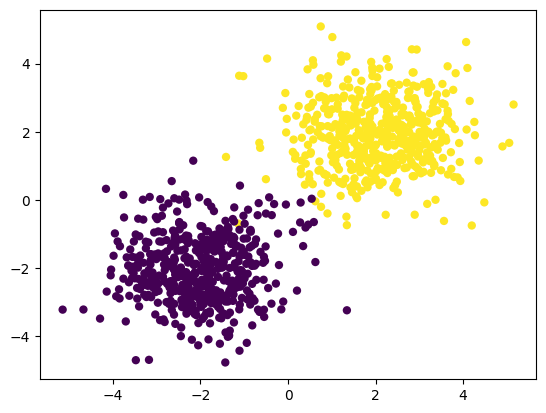

In [14]:
# Generate some data
N = 500

X1 = np.random.randn(N,2) + np.array([2,2])
X2 = np.random.randn(N,2) + np.array([-2,-2])

Y = np.concatenate([np.ones(N),np.zeros(N)])[:,None]
Y = np.hstack([Y, 1-Y])

X = np.vstack([X1,X2])
plt.scatter(X[:,0],X[:,1], c = Y[:,0], edgecolors= 'none')

Define a **logistic regression** for debugging. 

In [15]:
%run modules.ipynb

net = Sequential()
net.add(Linear(1000, 2))
net.add(LogSoftMax())

criterion = ClassNLLCriterion()
print(X.shape)
print(net)

# Test something like that then 

net = Sequential()
net.add(Linear(2, 4))
net.add(ReLU())
net.add(Linear(4, 2))
net.add(LogSoftMax())

(1000, 2)
Linear 1000 -> 2
LogSoftMax



<>:2: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_11302/2367876760.py:2: SyntaxWarning: invalid escape sequence '\g'
  """


Start with batch_size = 1000 to make sure every step lowers the loss, then try stochastic version.

In [16]:
# Iptimizer params
optimizer_config = {'learning_rate' : 1e-1, 'momentum': 0.9}
optimizer_state = {}

# Looping params
n_epoch = 20
batch_size = 128

In [17]:
# batch generator
def get_batches(dataset, batch_size):
    X, Y = dataset
    n_samples = X.shape[0]
        
    # Shuffle at the start of epoch
    indices = np.arange(n_samples)
    np.random.shuffle(indices)
    
    for start in range(0, n_samples, batch_size):
        end = min(start + batch_size, n_samples)
        
        batch_idx = indices[start:end]
    
        yield X[batch_idx], Y[batch_idx]

### Train

Basic training loop. Examine it.

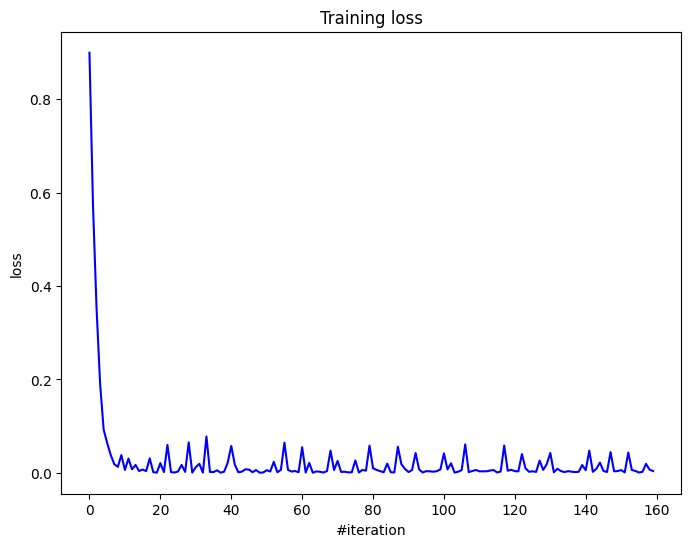

Current loss: 0.003796


In [18]:
%run modules.ipynb
loss_history = []

for i in range(n_epoch):
    for x_batch, y_batch in get_batches((X, Y), batch_size):
        
        net.zeroGradParameters()
        
        # Forward
        predictions = net.forward(x_batch)
        loss = criterion.forward(predictions, y_batch)
    
        # Backward
        dp = criterion.backward(predictions, y_batch)
        net.backward(x_batch, dp)
        
        # Update weights
        sgd_momentum(net.getParameters(), 
                     net.getGradParameters(), 
                     optimizer_config,
                     optimizer_state)      
        
        loss_history.append(loss)

    # Visualize
    display.clear_output(wait=True)
    plt.figure(figsize=(8, 6))
        
    plt.title("Training loss")
    plt.xlabel("#iteration")
    plt.ylabel("loss")
    plt.plot(loss_history, 'b')
    plt.show()
    
    print('Current loss: %f' % loss)    

# Digit classification 

We are using old good [MNIST](http://yann.lecun.com/exdb/mnist/) as our dataset.

In [19]:
import mnist
X_train, y_train, X_val, y_val, X_test, y_test = mnist.load_dataset(flatten=True)

One-hot encode the labels first.

In [20]:
def to_one_hot(y, num_classes=10):
    return np.eye(num_classes)[y]

y_train_oh = to_one_hot(y_train)
y_val_oh = to_one_hot(y_val)

- **Compare** `ReLU`, `ELU`, `LeakyReLU`, `SoftPlus` activation functions. 
You would better pick the best optimizer params for each of them, but it is overkill for now. Use an architecture of your choice for the comparison.
- **Try** inserting `BatchNormalization` (folowed by `ChannelwiseScaling`) between `Linear` module and activation functions.
- Plot the losses both from activation functions comparison and `BatchNormalization` comparison on one plot. Please find a scale (log?) when the lines are distinguishable, do not forget about naming the axes, the plot should be goodlooking.
- Plot the losses for two networks: one trained by momentum_sgd, another one trained by Adam. Which one performs better?
- Hint: good logloss for MNIST should be around 0.5. 

In [21]:
def fit(net, X, Y, criterion, n_epoch, batch_size,
        optimizer_fn, optimizer_config):
    
    loss_history = []
    optimizer_state = {}

    for epoch in range(n_epoch):
        for x_batch, y_batch in get_batches((X, Y), batch_size):

            net.zeroGradParameters()

            # Forward
            predictions = net.forward(x_batch)
            loss = criterion.forward(predictions, y_batch)

            # Backward
            dp = criterion.backward(predictions, y_batch)
            net.backward(x_batch, dp)

            # Update
            optimizer_fn(
                net.getParameters(),
                net.getGradParameters(),
                optimizer_config,
                optimizer_state
            )

            loss_history.append(loss)

    return loss_history

activations = {
    'ReLU': ReLU,
    'ELU': ELU,
    'LeakyReLU': LeakyReLU,
    'SoftPlus': SoftPlus
}

histories = {}

for name, activation in activations.items():
    net = Sequential()

    net.add(Linear(784, 256))
    net.add(activation())

    net.add(Linear(256, 128))
    net.add(activation())
    
    net.add(Linear(128, 10))
    net.add(LogSoftMax())

    histories[name] = fit(
    net=net,
    X=X_train,
    Y=y_train_oh,
    criterion=criterion,
    optimizer_fn=sgd_momentum,
    optimizer_config=optimizer_config,
    n_epoch=20,
    batch_size=128
    )

In [22]:
adam_config = {
    'learning_rate': 1e-3,
    'beta1': 0.9,
    'beta2': 0.999,
    'epsilon': 1e-8
}

histories_adam = {}

for name, activation in activations.items():
    net = Sequential()

    net.add(Linear(784, 256))
    net.add(activation())

    net.add(Linear(256, 128))
    net.add(activation())

    net.add(Linear(128, 10))
    net.add(LogSoftMax())

    histories_adam[name] = fit(
        net=net,
        X=X_train,
        Y=y_train_oh,
        criterion=criterion,
        optimizer_fn=adam_optimizer,
        optimizer_config=adam_config,
        n_epoch=20,
        batch_size=128
    )


In [23]:
#BatchNormalization
histories_bn = {}

for name, activation in activations.items():
    net = Sequential()

    net.add(Linear(784, 256))
    net.add(BatchNormalization(alpha=0.9))
    net.add(ChannelwiseScaling(256))
    net.add(activation())

    net.add(Linear(256, 128))
    net.add(BatchNormalization(alpha=0.9))
    net.add(ChannelwiseScaling(128))
    net.add(activation())

    net.add(Linear(128, 10))
    net.add(LogSoftMax())

    histories_bn[name] = fit(
        net=net,
        X=X_train,
        Y=y_train_oh,
        criterion=criterion,
        optimizer_fn=sgd_momentum,
        optimizer_config=optimizer_config,
        n_epoch=20,
        batch_size=128
    )

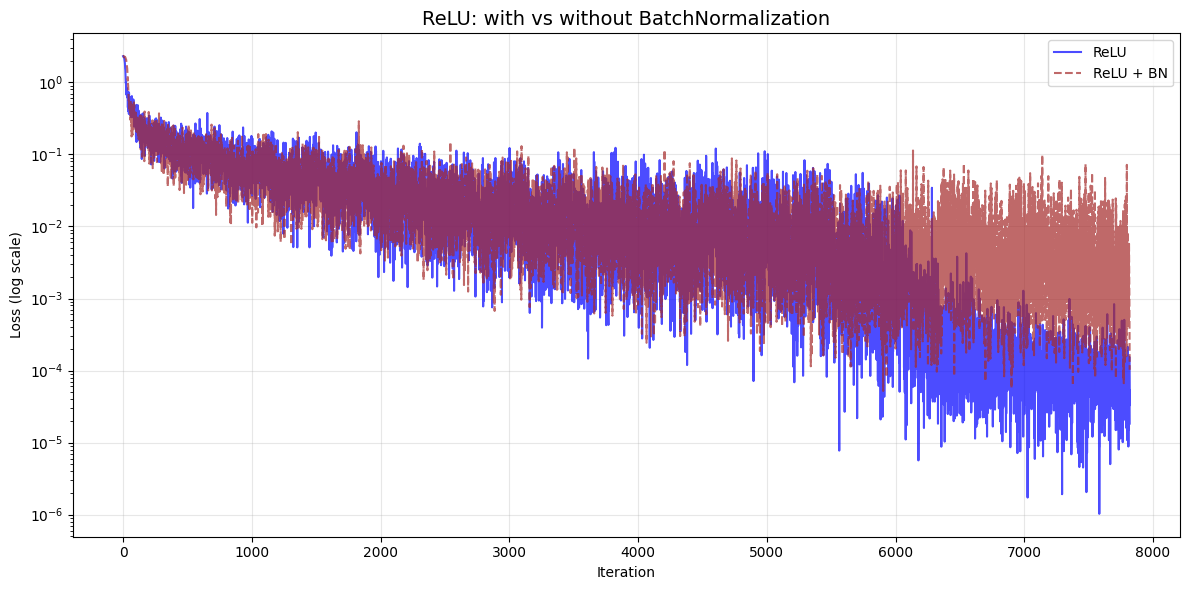

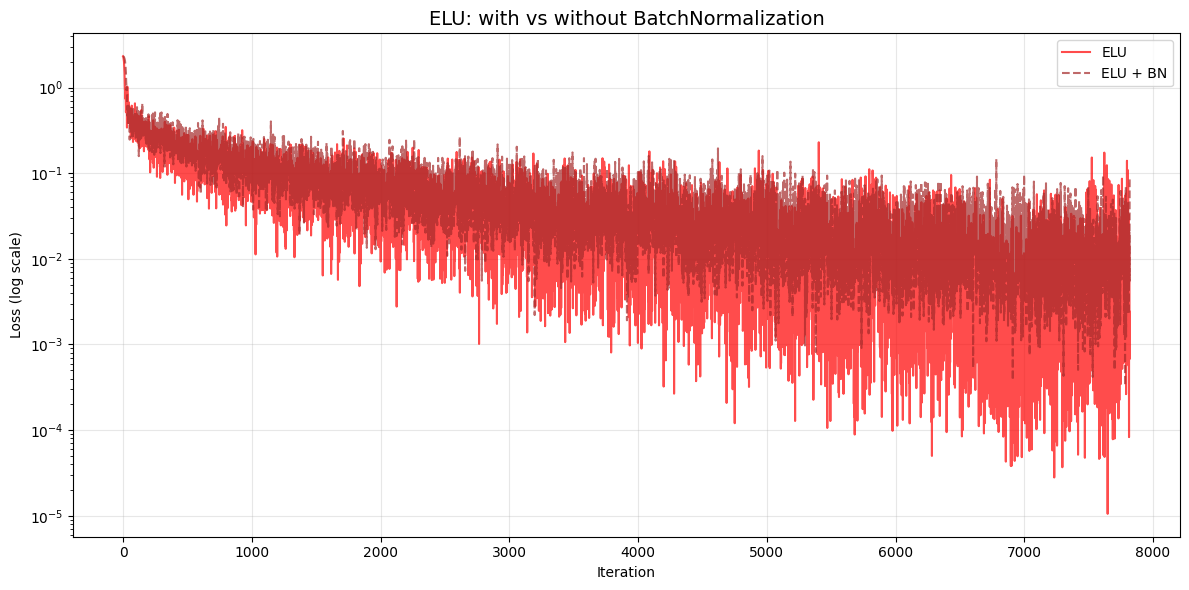

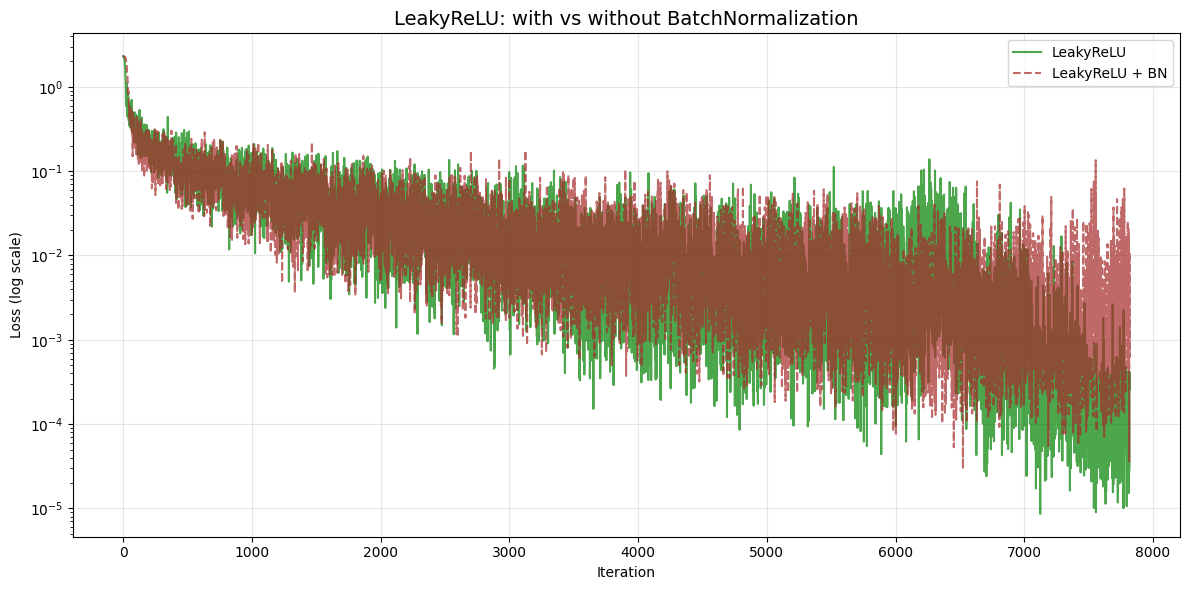

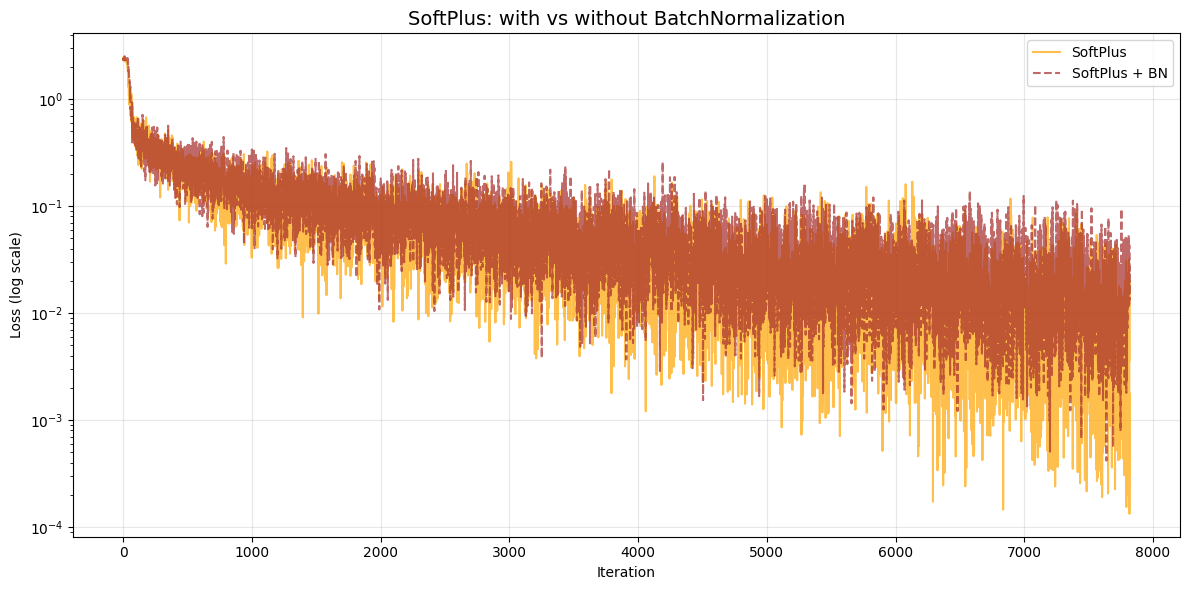

In [24]:
import matplotlib.pyplot as plt

colors = ['blue', 'red', 'green', 'orange']

for (name, history), color in zip(histories.items(), colors):
    history_bn = histories_bn[name]

    plt.figure(figsize=(12, 6))
    plt.title(f"{name}: with vs without BatchNormalization", fontsize=14)
    plt.xlabel("Iteration")
    plt.ylabel("Loss (log scale)")
    
    plt.plot(history, label=name, color=color, alpha=0.7)
    plt.plot(history_bn, label=f'{name} + BN', color='brown', linestyle='--', alpha=0.7)

    plt.yscale('log')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

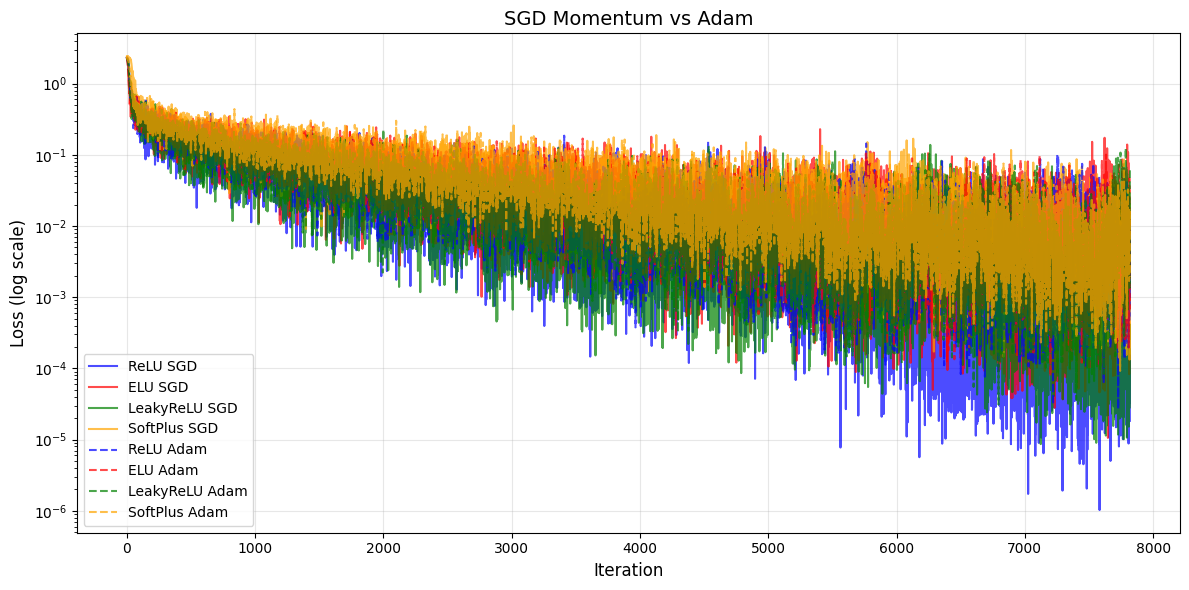

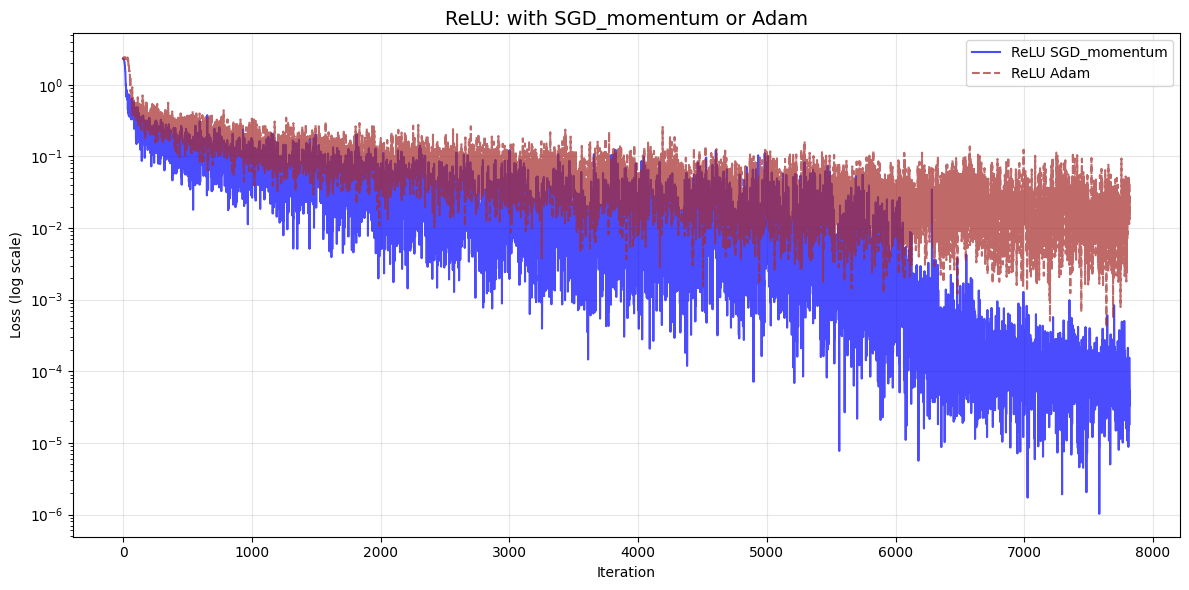

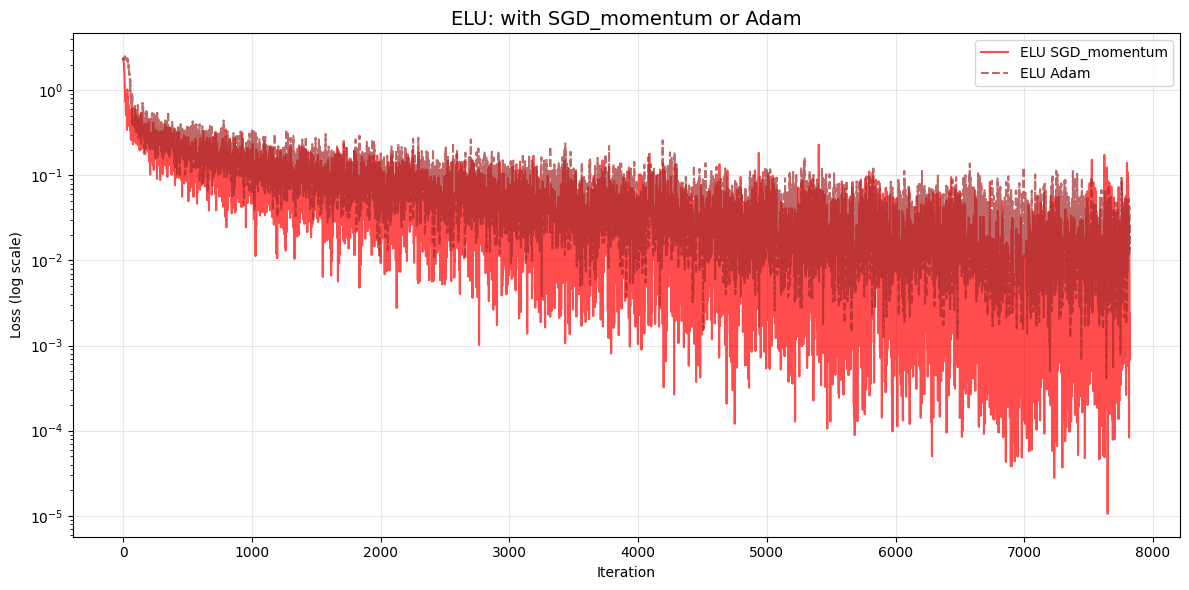

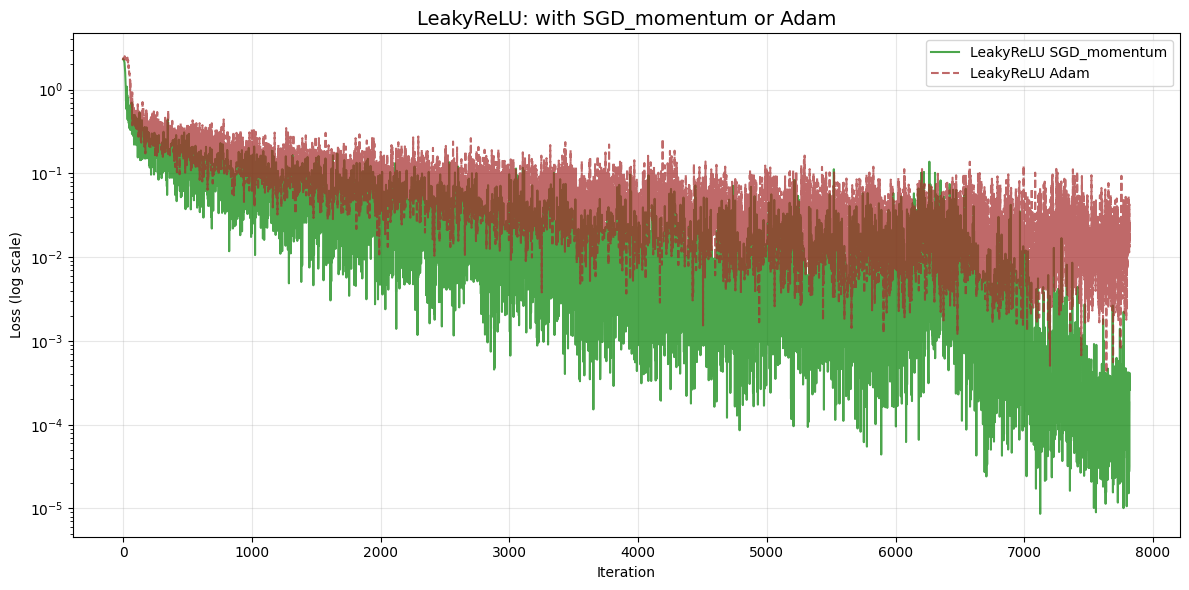

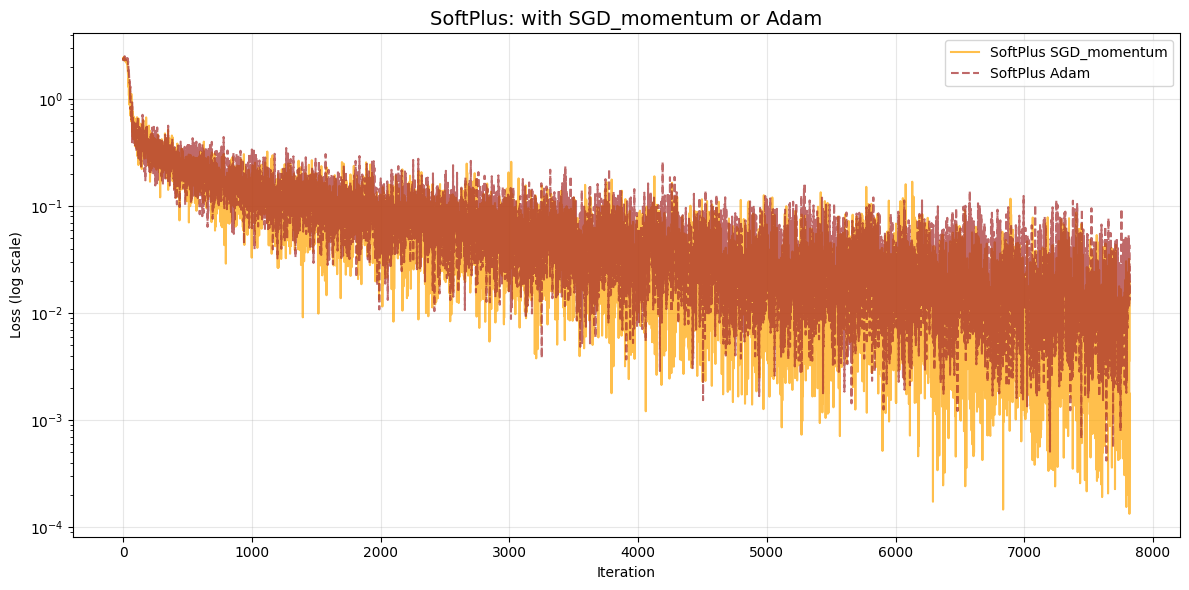

In [25]:
plt.figure(figsize=(12, 6))
plt.title("SGD Momentum vs Adam", fontsize=14)
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Loss (log scale)", fontsize=12)

for (name, history), color in zip(histories.items(), colors):
    plt.plot(history, label=f'{name} SGD', color=color, alpha=0.7)

for (name, history), color in zip(histories_adam.items(), colors):
    plt.plot(history, label=f'{name} Adam', color=color, linestyle='--', alpha=0.7)

plt.yscale('log')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for (name, history), color in zip(histories.items(), colors):
    history_adam = histories_adam[name]

    plt.figure(figsize=(12, 6))
    plt.title(f"{name}: with SGD_momentum or Adam", fontsize=14)
    plt.xlabel("Iteration")
    plt.ylabel("Loss (log scale)")
    
    plt.plot(history, label=f'{name} SGD_momentum', color=color, alpha=0.7)
    plt.plot(history_bn, label=f'{name} Adam', color='brown', linestyle='--', alpha=0.7)

    plt.yscale('log')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Write your personal opinion on the activation functions, think about computation times too. Does `BatchNormalization` help?

The graph shows that SGD with momentum achieves a lower training loss than Adam. This is due to several factors:

    Different learning rates: SGD uses a learning rate 100 times higher (0.1 vs. 0.001), allowing for larger steps.
    The nature of Adam: it adaptively reduces step sizes for parameters with large gradients, which prevents it from severely "overfitting" the training data.
    Task simplicity: MNIST is a "smooth" problem where SGD with momentum performs almost perfectly.

However, a lower training loss does not necessarily mean a better model. Adam typically demonstrates more stable training and better generalization to new data. For a fair comparison, one should look at validation loss or accuracy.

**Finally**, use all your knowledge to build a super cool model on this dataset. Use **dropout** to prevent overfitting, play with **learning rate decay**. You can use **data augmentation** such as rotations, translations to boost your score. Use your knowledge and imagination to train a model. Don't forget to call `training()` and `evaluate()` methods to set desired behaviour of `BatchNormalization` and `Dropout` layers.

In [26]:
import optuna
from sklearn.metrics import accuracy_score

def objective(trial):
    p             = trial.suggest_float('p', 0.2, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 0.001, 0.1, log=True)
    momentum      = trial.suggest_float('momentum', 0.9, 0.99)
    n_epoch       = trial.suggest_int('n_epoch', 10, 25)
    batch_size    = trial.suggest_categorical('batch_size', [32, 64, 128])

    net = Sequential()

    net.add(Linear(784, 256))
    net.add(BatchNormalization(alpha=0.9))
    net.add(ChannelwiseScaling(256))
    net.add(ReLU())
    net.add(Dropout(p=p))

    net.add(Linear(256, 128))
    net.add(BatchNormalization(alpha=0.9))
    net.add(ChannelwiseScaling(128))
    net.add(ReLU())
    net.add(Dropout(p=p))

    net.add(Linear(128, 10))
    net.add(LogSoftMax())

    net.train()

    optimizer_state = {}

    for i in range(n_epoch):
        for x_batch, y_batch in get_batches((X_train, y_train_oh), batch_size):
        
            net.zeroGradParameters()
        
            # Forward
            predictions = net.forward(x_batch)
            loss = criterion.forward(predictions, y_batch)
    
            # Backward
            dp = criterion.backward(predictions, y_batch)
            net.backward(x_batch, dp)
        
            # Update weights
            sgd_momentum(net.getParameters(), 
                        net.getGradParameters(), 
                        {'learning_rate' : learning_rate, 'momentum': momentum},
                        optimizer_state)

    net.evaluate()
    y_pred = net.forward(X_val)
    predicted_classes = np.argmax(y_pred, axis=1)

    accuracy = accuracy_score(y_val, predicted_classes)
    return accuracy

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)
print(study.best_params)


/home/dima/Документы/ml/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-07-25 17:00:06,803] A new study created in memory with name: no-name-e8783a8f-c340-4d69-87e1-7770a7330ca1
[I 2026-07-25 17:01:09,550] Trial 0 finished with value: 0.9806 and parameters: {'p': 0.3626142315623623, 'learning_rate': 0.01009254827509774, 'momentum': 0.960459779426223, 'n_epoch': 10, 'batch_size': 64}. Best is trial 0 with value: 0.9806.
[I 2026-07-25 17:02:56,565] Trial 1 finished with value: 0.9828 and parameters: {'p': 0.31016210513509135, 'learning_rate': 0.002301528201753042, 'momentum': 0.9825103305674713, 'n_epoch': 17, 'batch_size': 64}. Best is trial 1 with value: 0.9828.
[I 2026-07-25 17:07:00,938] Trial 2 finished with value: 0.9836 and parameters: {'p': 0.31577304250193605, 'learning_rate': 0.002

{'p': 0.31577304250193605, 'learning_rate': 0.0020253263415576923, 'momentum': 0.939122176960541, 'n_epoch': 23, 'batch_size': 32}


Print here your accuracy on test set. It should be around 90%.

In [27]:
print(study.best_value)

0.9836


In [28]:
print(study.best_params)

{'p': 0.31577304250193605, 'learning_rate': 0.0020253263415576923, 'momentum': 0.939122176960541, 'n_epoch': 23, 'batch_size': 32}


### Comparing with PyTorch implementation
The last (and maybe the easiest step after compared to the previous tasks: build a network with the same architecture as above now with PyTorch.

You can refer to the `week0_09` or `Lab3_part2` notebooks for hints.

__Good Luck!__

In [29]:
import torch.nn as nn
import torch
from sklearn.metrics import accuracy_score
from torch.utils.data import TensorDataset, DataLoader

net = nn.Sequential(
    nn.Linear(784, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.2731),

    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.2731),

    nn.Linear(128, 10)
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net  = net.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(net.parameters(), lr=0.0032, momentum=0.9135, weight_decay=5e-4)

num_epochs = 24
batch_size = 64

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t, y_val_t)

train_loader = DataLoader(train_dataset,
                          batch_size=batch_size, 
                          shuffle=True)
val_loader   = DataLoader(val_dataset,
                          batch_size=batch_size, 
                          shuffle=False)

for epoch in range(num_epochs):
    net.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        outputs = net(xb)
        loss = criterion(outputs, yb)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)

    epoch_train_loss = running_loss / len(train_loader.dataset)

    net.eval()
    running_val_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            outputs = net(xb)
            loss = criterion(outputs, yb)
            running_val_loss += loss.item() * xb.size(0)

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(yb.cpu().numpy())

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_acc = accuracy_score(all_targets, all_preds)

    print(f"Epoch [{epoch+1:2d}/{num_epochs}] | "
          f"Train Loss: {epoch_train_loss:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} | "
          f"Val Acc: {val_acc:.4f}")


/home/dima/Документы/ml/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


Epoch [ 1/24] | Train Loss: 0.4411 | Val Loss: 0.1477 | Val Acc: 0.9615
Epoch [ 2/24] | Train Loss: 0.2112 | Val Loss: 0.1095 | Val Acc: 0.9669
Epoch [ 3/24] | Train Loss: 0.1663 | Val Loss: 0.0936 | Val Acc: 0.9722
Epoch [ 4/24] | Train Loss: 0.1407 | Val Loss: 0.0856 | Val Acc: 0.9747
Epoch [ 5/24] | Train Loss: 0.1256 | Val Loss: 0.0775 | Val Acc: 0.9758
Epoch [ 6/24] | Train Loss: 0.1126 | Val Loss: 0.0767 | Val Acc: 0.9767
Epoch [ 7/24] | Train Loss: 0.1043 | Val Loss: 0.0713 | Val Acc: 0.9776
Epoch [ 8/24] | Train Loss: 0.0961 | Val Loss: 0.0688 | Val Acc: 0.9801
Epoch [ 9/24] | Train Loss: 0.0919 | Val Loss: 0.0675 | Val Acc: 0.9803
Epoch [10/24] | Train Loss: 0.0850 | Val Loss: 0.0649 | Val Acc: 0.9803
Epoch [11/24] | Train Loss: 0.0811 | Val Loss: 0.0653 | Val Acc: 0.9804
Epoch [12/24] | Train Loss: 0.0777 | Val Loss: 0.0632 | Val Acc: 0.9811
Epoch [13/24] | Train Loss: 0.0742 | Val Loss: 0.0615 | Val Acc: 0.9817
Epoch [14/24] | Train Loss: 0.0733 | Val Loss: 0.0610 | Val Acc: